CELL 1

In [ ]:
!pip install -q tensorflow opencv-python pandas numpy matplotlib scikit-learn pytesseract rapidfuzz

CELL 2

In [ ]:
!sudo apt-get update -qq
!sudo apt-get install -y tesseract-ocr

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (5.3.4-1build5).
0 upgraded, 0 newly installed, 0 to remove and 93 not upgraded.


CELL 3

In [ ]:
import os
import re
import glob
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import pytesseract

from sklearn.model_selection import train_test_split
from rapidfuzz.distance import Levenshtein

from tensorflow.keras import layers, models

print("TensorFlow:", tf.__version__)
print("OpenCV:", cv2.__version__)

TensorFlow: 2.20.0
OpenCV: 5.0.0


CELL 4

In [ ]:
print("GPU devices:")

for device in tf.config.list_physical_devices("GPU"):
    print(device)

GPU devices:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


CELL 5

In [ ]:
DATA_DIR = "/content/sample_data/dataset/br"

print("Dataset path:")
print(DATA_DIR)

print("\nFolder exists:", os.path.exists(DATA_DIR))

Dataset path:
/content/sample_data/dataset/br

Folder exists: True


CELL 6

In [ ]:
jpg_files = sorted(
    glob.glob(
        os.path.join(DATA_DIR, "*.jpg")
    )
)

print("Number of JPG files:", len(jpg_files))

Number of JPG files: 114


CELL 7

In [ ]:
txt_files = sorted(
    glob.glob(
        os.path.join(DATA_DIR, "*.txt")
    )
)

print("Number of TXT files:", len(txt_files))

Number of TXT files: 114


CELL 8

In [ ]:
records = []

for txt_path in txt_files:

    with open(
        txt_path,
        "r",
        encoding="utf-8"
    ) as f:

        line = f.readline().strip()

    if not line:
        continue

    parts = line.split()

    if len(parts) < 6:
        print(
            "Skipping malformed file:",
            txt_path
        )
        continue

    image_name = parts[0]

    x = float(parts[1])
    y = float(parts[2])
    width = float(parts[3])
    height = float(parts[4])

    plate_text = parts[5].strip().upper()

    image_path = os.path.join(
        DATA_DIR,
        image_name
    )

    if not os.path.exists(image_path):
        print(
            "Image missing:",
            image_path
        )
        continue

    records.append({
        "image_name": image_name,
        "image_path": image_path,
        "x": x,
        "y": y,
        "width": width,
        "height": height,
        "plate_text": plate_text
    })

df = pd.DataFrame(records)

print(
    "Total valid images:",
    len(df)
)

Total valid images: 114


CELL 9

In [ ]:
df.head(10)

,image_name,image_path,x,y,width,height,plate_text
0,AYO9034.jpg,/content/sample_data/dataset/br/AYO9034.jpg,528.0,412.0,162.0,52.0,AYO9034
1,AZJ6991.jpg,/content/sample_data/dataset/br/AZJ6991.jpg,560.0,642.0,236.0,76.0,AZJ6991
2,FZB9581.jpg,/content/sample_data/dataset/br/FZB9581.jpg,967.0,493.0,258.0,83.0,FZB9581
3,GWT2180.jpg,/content/sample_data/dataset/br/GWT2180.jpg,529.0,308.0,227.0,73.0,GWT2180
4,HPM9362.jpg,/content/sample_data/dataset/br/HPM9362.jpg,584.0,673.0,259.0,84.0,HPM9362
5,JGZ3298.jpg,/content/sample_data/dataset/br/JGZ3298.jpg,215.0,340.0,807.0,262.0,JGZ3298
6,JIT7463.jpg,/content/sample_data/dataset/br/JIT7463.jpg,215.0,502.0,150.0,48.0,JIT7463
7,JIY4434.jpg,/content/sample_data/dataset/br/JIY4434.jpg,687.0,351.0,218.0,70.0,JIY4434
8,JOG9221.jpg,/content/sample_data/dataset/br/JOG9221.jpg,522.0,572.0,257.0,83.0,JOG9221
9,JPQ9870.jpg,/content/sample_data/dataset/br/JPQ9870.jpg,571.0,623.0,320.0,104.0,JPQ9870


CELL 10

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   image_name  114 non-null    object 
 1   image_path  114 non-null    object 
 2   x           114 non-null    float64
 3   y           114 non-null    float64
 4   width       114 non-null    float64
 5   height      114 non-null    float64
 6   plate_text  114 non-null    object 
dtypes: float64(4), object(3)
memory usage: 6.4+ KB


CELL 11

In [ ]:
print(
    "Negative x:",
    (df["x"] < 0).sum()
)

print(
    "Negative y:",
    (df["y"] < 0).sum()
)

print(
    "Invalid width:",
    (df["width"] <= 0).sum()
)

print(
    "Invalid height:",
    (df["height"] <= 0).sum()
)

print(
    "Missing plate text:",
    df["plate_text"].isna().sum()
)

Negative x: 1
Negative y: 0
Invalid width: 0
Invalid height: 0
Missing plate text: 0


CELL 12

In [ ]:
def show_ground_truth(index):

    row = df.iloc[index]

    image = cv2.imread(row["image_path"])

    if image is None:
        print("Could not read:", row["image_path"])
        return

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    x = int(row["x"])
    y = int(row["y"])
    w = int(row["width"])
    h = int(row["height"])

    cv2.rectangle(
        image,
        (x, y),
        (x + w, y + h),
        (255, 0, 0),
        4
    )

    plt.figure(figsize=(12, 8))

    plt.imshow(image)

    plt.title(
        f"Ground Truth: {row['plate_text']}\n"
        f"x={x}, y={y}, width={w}, height={h}"
    )

    plt.axis("off")
    plt.show()

CELL 13

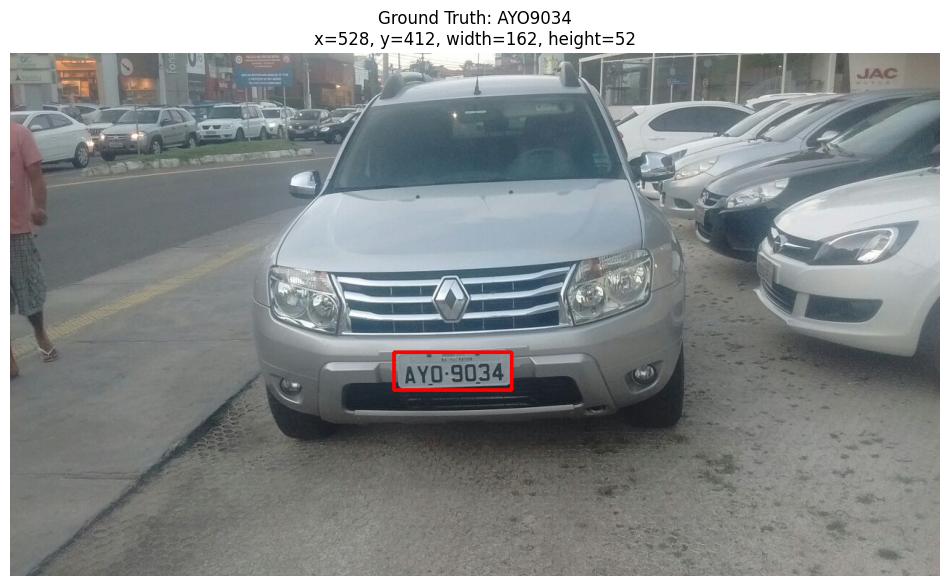

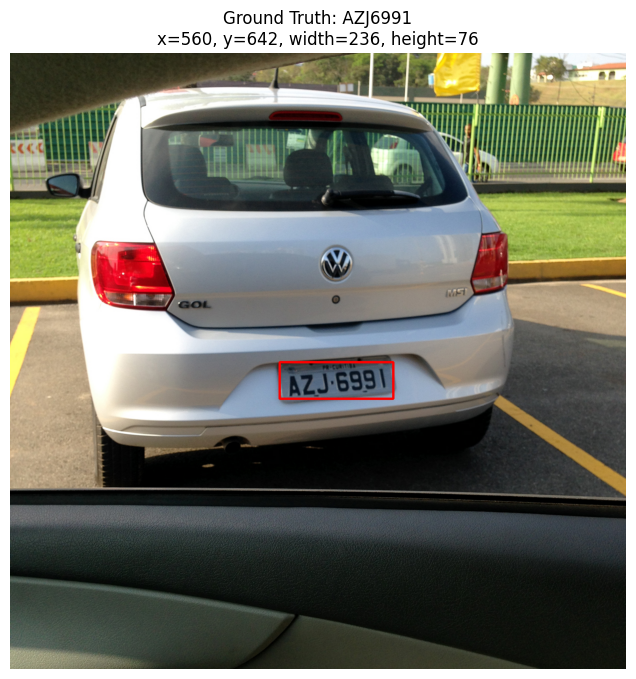

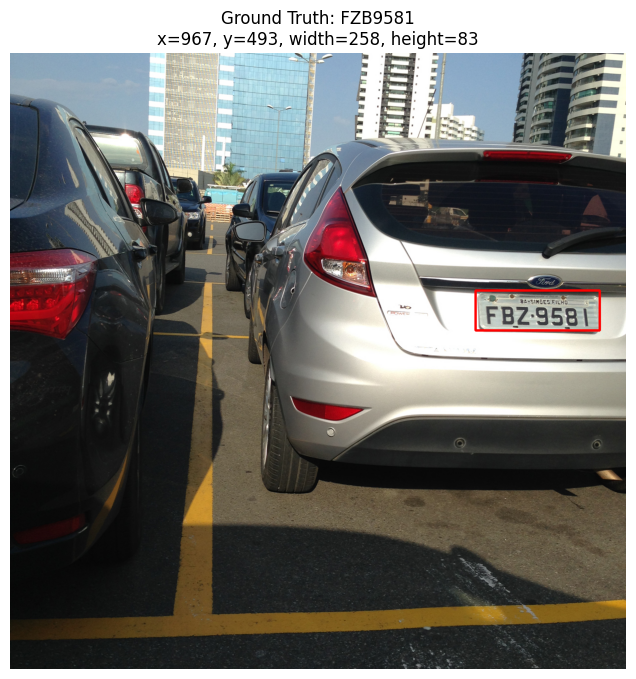

In [ ]:
show_ground_truth(0)
show_ground_truth(1)
show_ground_truth(2)

CELL 14

In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    shuffle=True
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    shuffle=True
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Training: 79
Validation: 17
Testing: 18


CELL 15

In [ ]:
IMG_SIZE = 320

print(
    "CNN input size:",
    IMG_SIZE,
    "x",
    IMG_SIZE
)

CNN input size: 320 x 320


CELL 16

In [ ]:
def load_images(dataframe):

    images = []

    for _, row in dataframe.iterrows():

        image = cv2.imread(
            row["image_path"]
        )

        if image is None:
            raise ValueError(
                "Could not read: "
                + row["image_path"]
            )

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        image = cv2.resize(
            image,
            (IMG_SIZE, IMG_SIZE)
        )

        image = (
            image.astype(
                np.float32
            ) / 255.0
        )

        images.append(image)

    return np.array(
        images,
        dtype=np.float32
    )

CELL 17

In [ ]:
X_train = load_images(
    train_df
)

X_val = load_images(
    val_df
)

X_test = load_images(
    test_df
)

print(
    "X_train:",
    X_train.shape
)

print(
    "X_val:",
    X_val.shape
)

print(
    "X_test:",
    X_test.shape
)

X_train: (79, 320, 320, 3)
X_val: (17, 320, 320, 3)
X_test: (18, 320, 320, 3)


CELL 18

In [ ]:
def create_mask(row):

    image = cv2.imread(
        row["image_path"]
    )

    if image is None:
        raise ValueError(
            "Could not read: "
            + row["image_path"]
        )

    original_h, original_w = (
        image.shape[:2]
    )

    x = row["x"]
    y = row["y"]
    w = row["width"]
    h = row["height"]

    scale_x = (
        IMG_SIZE /
        original_w
    )

    scale_y = (
        IMG_SIZE /
        original_h
    )

    x1 = int(x * scale_x)
    y1 = int(y * scale_y)

    x2 = int(
        (x + w) * scale_x
    )

    y2 = int(
        (y + h) * scale_y
    )

    x1 = max(
        0,
        min(IMG_SIZE - 1, x1)
    )

    y1 = max(
        0,
        min(IMG_SIZE - 1, y1)
    )

    x2 = max(
        1,
        min(IMG_SIZE, x2)
    )

    y2 = max(
        1,
        min(IMG_SIZE, y2)
    )

    mask = np.zeros(
        (IMG_SIZE, IMG_SIZE, 1),
        dtype=np.float32
    )

    mask[
        y1:y2,
        x1:x2,
        0
    ] = 1.0

    return mask

CELL 19

In [ ]:
def create_masks(dataframe):

    masks = []

    for _, row in dataframe.iterrows():

        masks.append(
            create_mask(row)
        )

    return np.array(
        masks,
        dtype=np.float32
    )

CELL 20

In [ ]:
Y_train = create_masks(
    train_df
)

Y_val = create_masks(
    val_df
)

Y_test = create_masks(
    test_df
)

print(
    "Y_train:",
    Y_train.shape
)

print(
    "Y_val:",
    Y_val.shape
)

print(
    "Y_test:",
    Y_test.shape
)

Y_train: (79, 320, 320, 1)
Y_val: (17, 320, 320, 1)
Y_test: (18, 320, 320, 1)


CELL 21

In [ ]:
def show_mask(index):

    image = X_train[index]

    mask = Y_train[
        index,
        :, :,
        0
    ]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)

    plt.imshow(image)

    plt.title(
        "Original Image"
    )

    plt.axis("off")

    plt.subplot(1, 2, 2)

    plt.imshow(
        mask,
        cmap="gray"
    )

    plt.title(
        "CNN Target Mask"
    )

    plt.axis("off")

    plt.show()

CELL 22

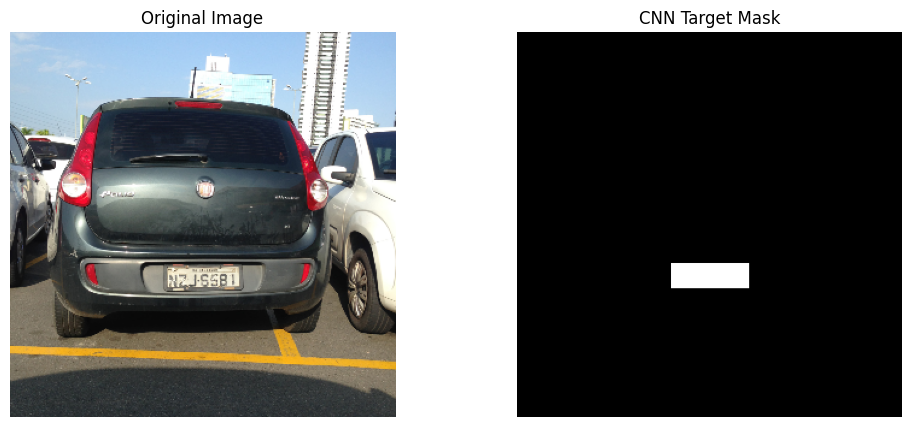

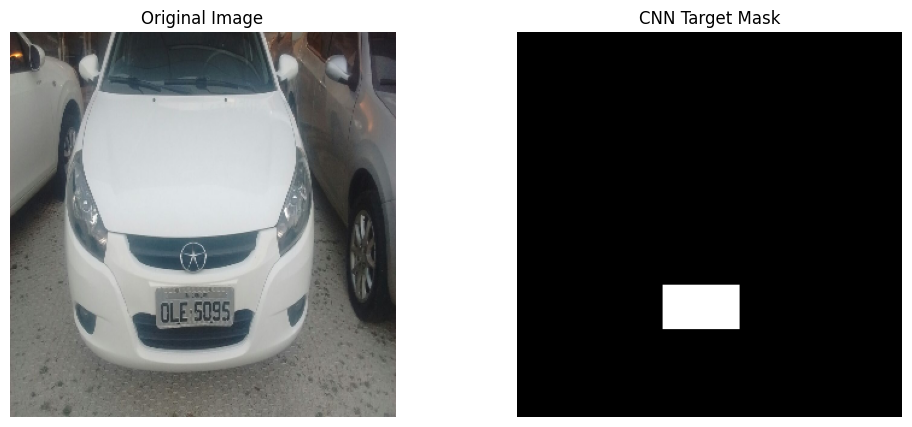

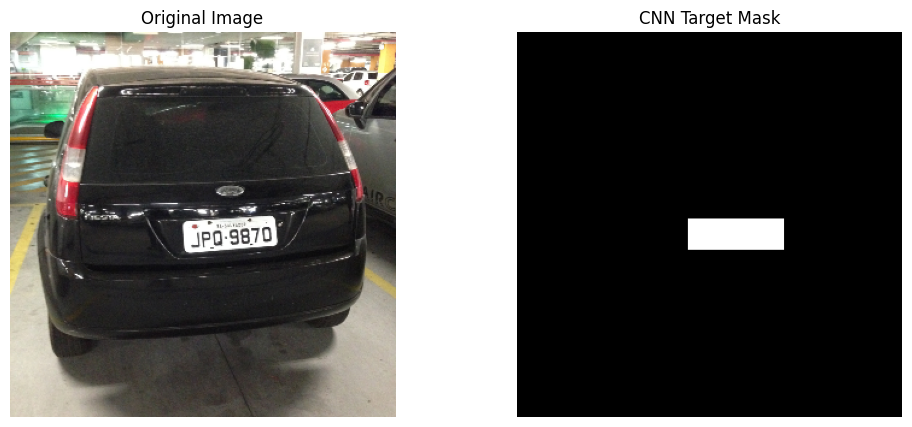

In [ ]:
show_mask(0)
show_mask(1)
show_mask(2)

CELL 23

In [ ]:
def conv_block(x, filters):

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    return x

CELL 24

In [ ]:
inputs = layers.Input(
    shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    )
)

# Encoder
c1 = conv_block(
    inputs,
    32
)

p1 = layers.MaxPooling2D(
    2
)(c1)


c2 = conv_block(
    p1,
    64
)

p2 = layers.MaxPooling2D(
    2
)(c2)


c3 = conv_block(
    p2,
    128
)

p3 = layers.MaxPooling2D(
    2
)(c3)


# Bottleneck
b = conv_block(
    p3,
    256
)


# Decoder
u3 = layers.UpSampling2D(
    2
)(b)

u3 = layers.Concatenate()(
    [u3, c3]
)

c4 = conv_block(
    u3,
    128
)


u2 = layers.UpSampling2D(
    2
)(c4)

u2 = layers.Concatenate()(
    [u2, c2]
)

c5 = conv_block(
    u2,
    64
)


u1 = layers.UpSampling2D(
    2
)(c5)

u1 = layers.Concatenate()(
    [u1, c1]
)

c6 = conv_block(
    u1,
    32
)


# Final mask
outputs = layers.Conv2D(
    1,
    1,
    activation="sigmoid"
)(c6)


model = models.Model(
    inputs=inputs,
    outputs=outputs
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 320, 320,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 320, 320,  │        896 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 320,  │        128 │ conv2d_38[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 320, 320,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 320,  │        128 │ conv2d_39[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 160, 160,  │     18,496 │ max_pooling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        256 │ conv2d_40[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 160, 160,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        256 │ conv2d_41[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 80, 80,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 80, 80,    │     73,856 │ max_pooling2d_10… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        512 │ conv2d_42[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 80, 80,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        512 │ conv2d_43[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 40, 40,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 40, 40,    │    295,168 │ max_pooling2d_11

 Total params: 1,952,513 (7.45 MB)

 Trainable params: 1,949,697 (7.44 MB)

 Non-trainable params: 2,816 (11.00 KB)

CELL 25

In [ ]:
def dice_loss(
    y_true,
    y_pred
):

    smooth = 1e-6

    y_true_f = tf.reshape(
        y_true,
        [-1]
    )

    y_pred_f = tf.reshape(
        y_pred,
        [-1]
    )

    intersection = tf.reduce_sum(
        y_true_f * y_pred_f
    )

    dice = (
        2.0 * intersection
        + smooth
    ) / (
        tf.reduce_sum(y_true_f)
        +
        tf.reduce_sum(y_pred_f)
        +
        smooth
    )

    return 1.0 - dice

CELL 26

In [ ]:
def combined_loss(
    y_true,
    y_pred
):

    bce = tf.reduce_mean(
        tf.keras.losses.binary_crossentropy(
            y_true,
            y_pred
        )
    )

    dice = dice_loss(
        y_true,
        y_pred
    )

    return bce + dice

CELL 27

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=combined_loss
)

print(
    "CNN compiled successfully."
)

CNN compiled successfully.


CELL 28

In [ ]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7
    )
]

CELL 29

In [ ]:
history = model.fit(

    X_train,
    Y_train,

    validation_data=(
        X_val,
        Y_val
    ),

    epochs=100,

    batch_size=4,

    callbacks=callbacks,

    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 36s 777ms/step - loss: 1.6821 - val_loss: 1.6246 - learning_rate: 1.0000e-04
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - loss: 1.5908 - val_loss: 1.5767 - learning_rate: 1.0000e-04
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - loss: 1.5384 - val_loss: 1.4945 - learning_rate: 1.0000e-04
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - loss: 1.5100 - val_loss: 1.4526 - learning_rate: 1.0000e-04
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - loss: 1.4974 - val_loss: 1.4062 - learning_rate: 1.0000e-04
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - loss: 1.4829 - val_loss: 1.3927 - learning_rate: 1.0000e-04
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - loss: 1.4606 - val_loss: 1.3623 - learning_rate: 1.0000e-04
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - loss: 1.4483 - val_loss: 1.3392 - learning_rate: 1.0000e-04
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - loss: 1.4327 - val_loss:

CELL 30

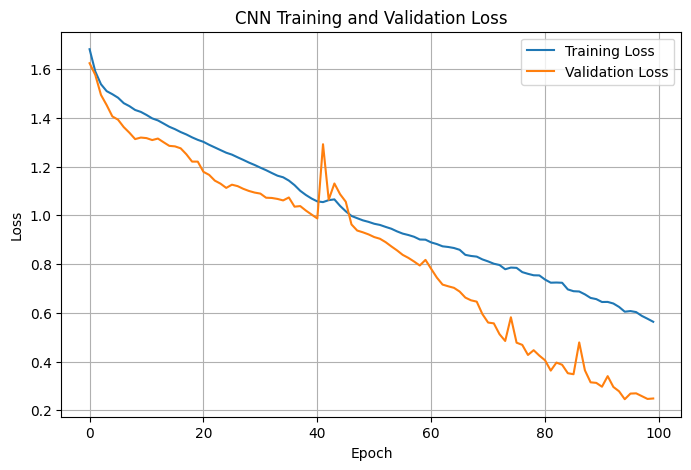

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "CNN Training and Validation Loss"
)

plt.legend()

plt.grid(True)

plt.show()

CELL 31

In [ ]:
predicted_masks = model.predict(
    X_test,
    verbose=1
)

print(
    "Prediction shape:",
    predicted_masks.shape
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction shape: (18, 320, 320, 1)


CELL 32

In [ ]:
def mask_to_box(mask, threshold=0.5):

    binary = (
        mask >= threshold
    ).astype(np.uint8) * 255

    kernel = np.ones(
        (5, 5),
        np.uint8
    )

    binary = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        kernel
    )

    binary = cv2.morphologyEx(
        binary,
        cv2.MORPH_CLOSE,
        kernel
    )

    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return None

    contour = max(
        contours,
        key=cv2.contourArea
    )

    if cv2.contourArea(contour) < 20:
        return None

    x, y, w, h = cv2.boundingRect(
        contour
    )

    return np.array(
        [
            x / IMG_SIZE,
            y / IMG_SIZE,
            w / IMG_SIZE,
            h / IMG_SIZE
        ],
        dtype=np.float32
    )

CELL 33

In [ ]:
predicted_boxes = []

for i in range(
    len(predicted_masks)
):

    box = mask_to_box(
        predicted_masks[
            i,
            :,
            :,
            0
        ]
    )

    predicted_boxes.append(
        box
    )

print(
    "Total predictions:",
    len(predicted_boxes)
)

print(
    "First predicted box:",
    predicted_boxes[0]
)

Total predictions: 18
First predicted box: [0.4      0.471875 0.184375 0.06875 ]


CELL 34

In [ ]:
def create_normalized_boxes(
    dataframe
):

    boxes = []

    for _, row in dataframe.iterrows():

        image = cv2.imread(
            row["image_path"]
        )

        h, w = image.shape[:2]

        box = np.array(
            [
                row["x"] / w,
                row["y"] / h,
                row["width"] / w,
                row["height"] / h
            ],
            dtype=np.float32
        )

        boxes.append(box)

    return np.array(
        boxes
    )

CELL 35

In [ ]:
ground_truth_boxes = (
    create_normalized_boxes(
        test_df
    )
)

print(
    ground_truth_boxes.shape
)

(18, 4)


CELL 36

In [ ]:
def calculate_iou(
    box1,
    box2
):

    if box2 is None:
        return 0.0

    x1, y1, w1, h1 = box1

    x2, y2, w2, h2 = box2

    xa = max(
        x1,
        x2
    )

    ya = max(
        y1,
        y2
    )

    xb = min(
        x1 + w1,
        x2 + w2
    )

    yb = min(
        y1 + h1,
        y2 + h2
    )

    intersection_width = max(
        0,
        xb - xa
    )

    intersection_height = max(
        0,
        yb - ya
    )

    intersection = (
        intersection_width *
        intersection_height
    )

    area1 = w1 * h1

    area2 = w2 * h2

    union = (
        area1 +
        area2 -
        intersection
    )

    if union <= 0:
        return 0.0

    return (
        intersection /
        union
    )

CELL 37

In [ ]:
ious = []

for true_box, pred_box in zip(
    ground_truth_boxes,
    predicted_boxes
):

    iou = calculate_iou(
        true_box,
        pred_box
    )

    ious.append(iou)

ious = np.array(
    ious
)

print(
    "Mean IoU:",
    f"{np.mean(ious):.4f}"
)

print(
    "Median IoU:",
    f"{np.median(ious):.4f}"
)

print(
    "Detection rate IoU >= 0.50:",
    f"{np.mean(ious >= 0.50) * 100:.2f}%"
)

print(
    "Detection rate IoU >= 0.75:",
    f"{np.mean(ious >= 0.75) * 100:.2f}%"
)

Mean IoU: 0.7994
Median IoU: 0.8394
Detection rate IoU >= 0.50: 94.44%
Detection rate IoU >= 0.75: 77.78%


CELL 38

In [ ]:
def show_prediction(index):

    image = X_test[index].copy()

    image = (
        image * 255
    ).clip(
        0, 255
    ).astype(
        np.uint8
    )

    true_box = ground_truth_boxes[index]
    pred_box = predicted_boxes[index]

    h, w = image.shape[:2]

    # Ground truth
    tx = int(true_box[0] * w)
    ty = int(true_box[1] * h)
    tw = int(true_box[2] * w)
    th = int(true_box[3] * h)

    cv2.rectangle(
        image,
        (tx, ty),
        (tx + tw, ty + th),
        (255, 0, 0),
        3
    )

    # CNN prediction
    if pred_box is not None:

        px = int(pred_box[0] * w)
        py = int(pred_box[1] * h)
        pw = int(pred_box[2] * w)
        ph = int(pred_box[3] * h)

        cv2.rectangle(
            image,
            (px, py),
            (px + pw, py + ph),
            (0, 255, 0),
            3
        )

    plt.figure(figsize=(12, 8))

    plt.imshow(image)

    plt.title(
        f"BLUE = Ground Truth | GREEN = CNN Prediction\n"
        f"IoU = {ious[index]:.3f}"
    )

    plt.axis("off")
    plt.show()

CELL 39

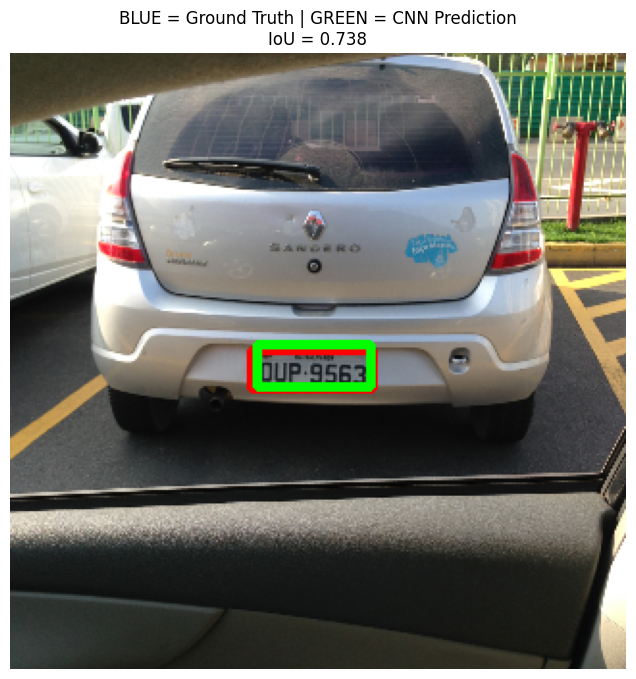

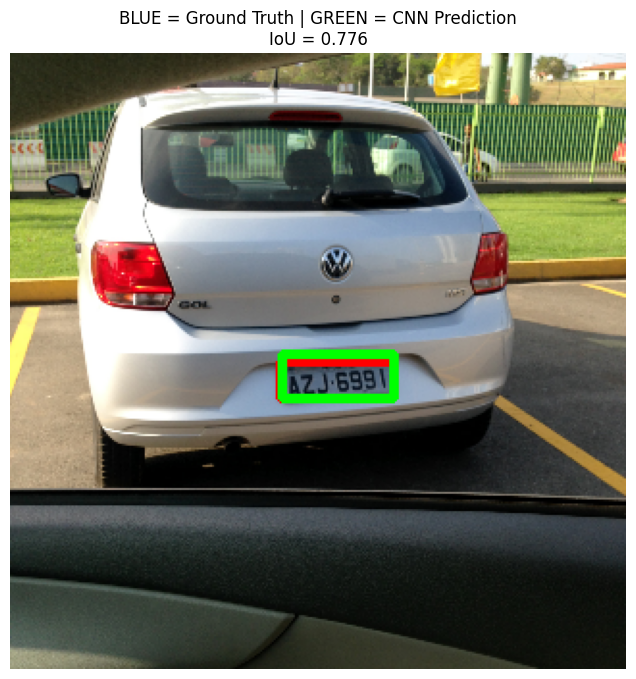

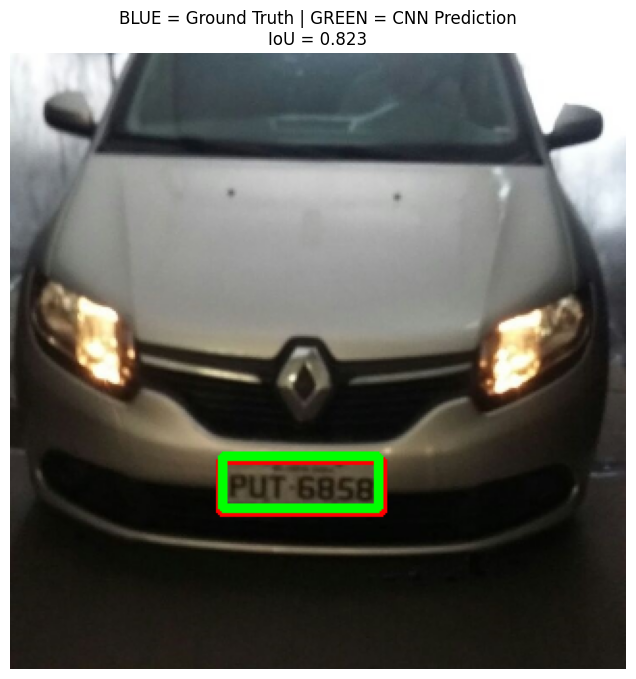

In [ ]:
show_prediction(0)
show_prediction(1)
show_prediction(2)

CELL 40

In [ ]:
cnn_results = test_df.copy()

cnn_results["IoU"] = ious

cnn_results["detected"] = (
    cnn_results["IoU"] >= 0.50
)

cnn_results[
    [
        "image_name",
        "plate_text",
        "IoU",
        "detected"
    ]
].head(20)

,image_name,plate_text,IoU,detected
0,OUP9563.jpg,OUP9563,0.738177,True
1,AZJ6991.jpg,AZJ6991,0.776411,True
2,PUT6858.jpg,PUT6858,0.823418,True
3,PJJ4955.jpg,PJJ4955,0.890185,True
4,OZU5764.jpg,OZU5764,0.639962,True
5,JSG9648.jpg,JSG9648,0.677594,True
6,OKM0944.jpg,OKM0944,0.775407,True
7,OZL2318.jpg,OZL2318,0.776811,True
8,PVX0095.jpg,PVX0095,0.293672,False
9,PJC4903.jpg,PJC4903,0.882446,True


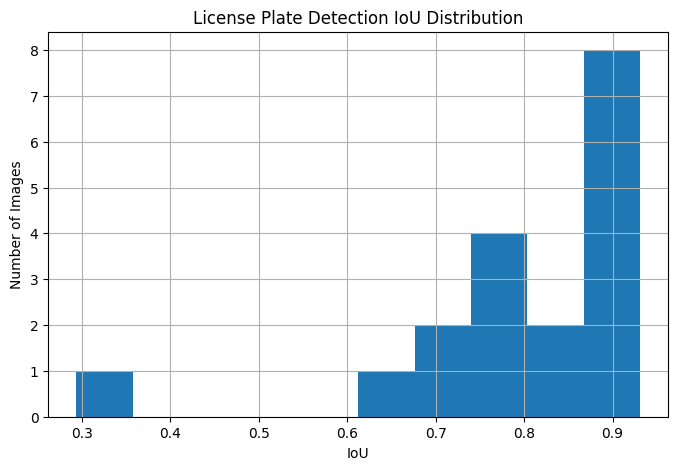

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    ious,
    bins=10
)

plt.xlabel("IoU")
plt.ylabel("Number of Images")

plt.title(
    "License Plate Detection IoU Distribution"
)

plt.grid(True)

plt.show()

In [ ]:
def get_predicted_plate(index):

    image = X_test[
        index
    ]

    box = predicted_boxes[
        index
    ]

    if box is None:
        return None

    h, w = image.shape[:2]

    x = int(
        box[0] * w
    )

    y = int(
        box[1] * h
    )

    bw = int(
        box[2] * w
    )

    bh = int(
        box[3] * h
    )

    # Add small padding
    pad_x = int(
        bw * 0.10
    )

    pad_y = int(
        bh * 0.15
    )

    x1 = max(
        0,
        x - pad_x
    )

    y1 = max(
        0,
        y - pad_y
    )

    x2 = min(
        w,
        x + bw + pad_x
    )

    y2 = min(
        h,
        y + bh + pad_y
    )

    if (
        x2 <= x1
        or
        y2 <= y1
    ):
        return None

    return image[
        y1:y2,
        x1:x2
    ]

In [ ]:
def preprocess_plate(
    plate
):

    if plate is None:
        return None

    plate_uint8 = np.clip(
        plate * 255,
        0,
        255
    ).astype(
        np.uint8
    )

    gray = cv2.cvtColor(
        plate_uint8,
        cv2.COLOR_RGB2GRAY
    )

    # Enlarge
    gray = cv2.resize(
        gray,
        None,
        fx=4,
        fy=4,
        interpolation=cv2.INTER_CUBIC
    )

    # Reduce noise
    gray = cv2.GaussianBlur(
        gray,
        (3, 3),
        0
    )

    # Otsu threshold
    threshold = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY +
        cv2.THRESH_OTSU
    )[1]

    return threshold

In [ ]:
def clean_ocr_text(
    text
):

    text = text.upper()

    text = re.sub(
        r"[^A-Z0-9]",
        "",
        text
    )

    return text

In [ ]:
def run_ocr(
    plate
):

    processed = preprocess_plate(
        plate
    )

    if processed is None:
        return ""

    text = pytesseract.image_to_string(
        processed,
        config="--psm 7"
    )

    return clean_ocr_text(
        text
    )

In [ ]:
def show_ocr_prediction(
    index
):

    plate = get_predicted_plate(
        index
    )

    row = test_df.iloc[
        index
    ]

    predicted_text = run_ocr(
        plate
    )

    print(
        "Ground Truth:",
        row["plate_text"]
    )

    print(
        "OCR Prediction:",
        predicted_text
    )

    if plate is None:

        print(
            "No valid CNN plate crop."
        )

        return

    processed = preprocess_plate(
        plate
    )

    plt.figure(
        figsize=(12, 5)
    )

    plt.subplot(
        1,
        2,
        1
    )

    plt.imshow(
        plate
    )

    plt.title(
        "CNN Predicted Plate Crop"
    )

    plt.axis("off")


    plt.subplot(
        1,
        2,
        2
    )

    plt.imshow(
        processed,
        cmap="gray"
    )

    plt.title(
        f"OCR: {predicted_text}"
    )

    plt.axis("off")

    plt.show()

Ground Truth: OUP9563
OCR Prediction: OUP9563


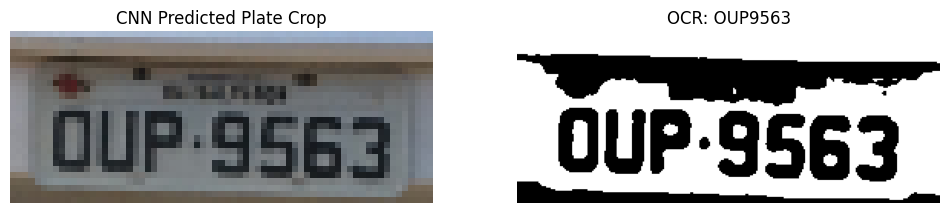

Ground Truth: OZL2318
OCR Prediction: OZ02318


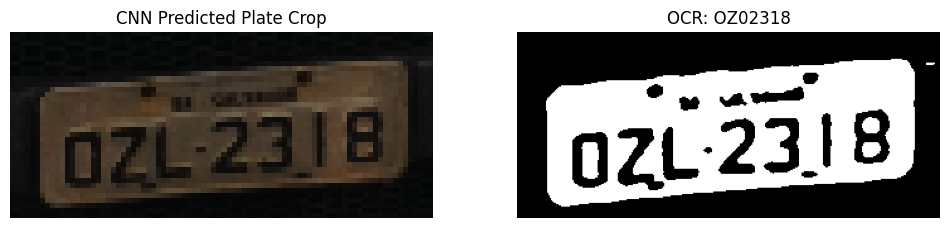

Ground Truth: PJC4903
OCR Prediction: PJC4903


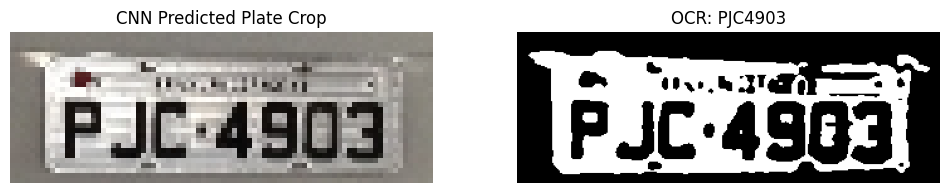

In [ ]:
show_ocr_prediction(0)
show_ocr_prediction(7)
show_ocr_prediction(9)

In [ ]:
ocr_predictions = []

for i in range(
    len(test_df)
):

    plate = get_predicted_plate(
        i
    )

    prediction = run_ocr(
        plate
    )

    ocr_predictions.append(
        prediction
    )

print(
    "Number of OCR predictions:",
    len(ocr_predictions)
)

Number of OCR predictions: 18


In [ ]:
ocr_results = test_df.copy()

ocr_results[
    "ocr_prediction"
] = ocr_predictions

ocr_results[
    "exact_match"
] = (
    ocr_results["plate_text"]
    ==
    ocr_results["ocr_prediction"]
)

ocr_results.head(20)

,image_name,image_path,x,y,width,height,plate_text,ocr_prediction,exact_match
0,OUP9563.jpg,/content/sample_data/dataset/br/OUP9563.jpg,502.0,617.0,255.0,82.0,OUP9563,OUP9563,True
1,AZJ6991.jpg,/content/sample_data/dataset/br/AZJ6991.jpg,560.0,642.0,236.0,76.0,AZJ6991,,False
2,PUT6858.jpg,/content/sample_data/dataset/br/PUT6858.jpg,247.0,475.0,189.0,61.0,PUT6858,2,False
3,PJJ4955.jpg,/content/sample_data/dataset/br/PJJ4955.jpg,397.0,678.0,312.0,101.0,PJJ4955,PJJ4G6E,False
4,OZU5764.jpg,/content/sample_data/dataset/br/OZU5764.jpg,431.0,341.0,338.0,109.0,OZU5764,07U5764,False
5,JSG9648.jpg,/content/sample_data/dataset/br/JSG9648.jpg,571.0,570.0,227.0,73.0,JSG9648,,False
6,OKM0944.jpg,/content/sample_data/dataset/br/OKM0944.jpg,300.0,595.0,226.0,73.0,OKM0944,OKN844,False
7,OZL2318.jpg,/content/sample_data/dataset/br/OZL2318.jpg,592.0,800.0,299.0,97.0,OZL2318,OZ02318,False
8,PVX0095.jpg,/content/sample_data/dataset/br/PVX0095.jpg,34.0,115.0,460.0,149.0,PVX0095,009,False
9,PJC4903.jpg,/content/sample_data/dataset/br/PJC4903.jpg,540.0,750.0,289.0,93.0,PJC4903,PJC4903,True


In [ ]:
exact_accuracy = (
    ocr_results[
        "exact_match"
    ].mean()
)

print(
    "Exact Plate Accuracy:",
    f"{exact_accuracy * 100:.2f}%"
)

Exact Plate Accuracy: 22.22%


In [ ]:
def character_accuracy(
    true_text,
    predicted_text
):

    true_text = str(
        true_text
    )

    predicted_text = str(
        predicted_text
    )

    if len(true_text) == 0:
        return 0.0

    distance = (
        Levenshtein.distance(
            true_text,
            predicted_text
        )
    )

    accuracy = (
        1 -
        distance / len(true_text)
    )

    return max(
        0.0,
        accuracy
    )

In [ ]:
char_accuracy_values = []

for true_text, pred_text in zip(
    ocr_results[
        "plate_text"
    ],
    ocr_results[
        "ocr_prediction"
    ]
):

    value = character_accuracy(
        true_text,
        pred_text
    )

    char_accuracy_values.append(
        value
    )

ocr_results[
    "character_accuracy"
] = char_accuracy_values

print(
    "Character Accuracy:",
    f"{np.mean(char_accuracy_values) * 100:.2f}%"
)

Character Accuracy: 47.62%


In [ ]:
def character_prf(
    true_text,
    pred_text
):

    true_text = str(
        true_text
    )

    pred_text = str(
        pred_text
    )

    operations = (
        Levenshtein.editops(
            true_text,
            pred_text
        )
    )

    substitutions = sum(
        operation.tag == "replace"
        for operation in operations
    )

    deletions = sum(
        operation.tag == "delete"
        for operation in operations
    )

    insertions = sum(
        operation.tag == "insert"
        for operation in operations
    )

    true_positive = max(
        0,
        len(true_text)
        -
        substitutions
        -
        deletions
    )

    false_positive = (
        substitutions
        +
        insertions
    )

    false_negative = (
        substitutions
        +
        deletions
    )

    if (
        true_positive
        +
        false_positive
    ) > 0:

        precision = (
            true_positive /
            (
                true_positive
                +
                false_positive
            )
        )

    else:

        precision = 0.0


    if (
        true_positive
        +
        false_negative
    ) > 0:

        recall = (
            true_positive /
            (
                true_positive
                +
                false_negative
            )
        )

    else:

        recall = 0.0


    if (
        precision + recall
    ) > 0:

        f1 = (
            2 *
            precision *
            recall /
            (
                precision +
                recall
            )
        )

    else:

        f1 = 0.0

    return (
        precision,
        recall,
        f1
    )

In [ ]:
prf_values = []

for true_text, pred_text in zip(
    ocr_results[
        "plate_text"
    ],
    ocr_results[
        "ocr_prediction"
    ]
):

    values = character_prf(
        true_text,
        pred_text
    )

    prf_values.append(
        values
    )


ocr_results[
    "char_precision"
] = [
    value[0]
    for value in prf_values
]


ocr_results[
    "char_recall"
] = [
    value[1]
    for value in prf_values
]


ocr_results[
    "char_f1"
] = [
    value[2]
    for value in prf_values
]

In [ ]:
print(
    "Character Precision:",
    f"{ocr_results['char_precision'].mean() * 100:.2f}%"
)

print(
    "Character Recall:",
    f"{ocr_results['char_recall'].mean() * 100:.2f}%"
)

print(
    "Character F1:",
    f"{ocr_results['char_f1'].mean() * 100:.2f}%"
)

Character Precision: 51.85%
Character Recall: 48.41%
Character F1: 49.46%


In [ ]:
ocr_results[
    [
        "image_name",
        "plate_text",
        "ocr_prediction",
        "exact_match",
        "character_accuracy",
        "char_precision",
        "char_recall",
        "char_f1"
    ]
].head(20)

,image_name,plate_text,ocr_prediction,exact_match,character_accuracy,char_precision,char_recall,char_f1
0,OUP9563.jpg,OUP9563,OUP9563,True,1.000000,1.000000,1.000000,1.000000
1,AZJ6991.jpg,AZJ6991,,False,0.000000,0.000000,0.000000,0.000000
2,PUT6858.jpg,PUT6858,2,False,0.000000,0.000000,0.000000,0.000000
3,PJJ4955.jpg,PJJ4955,PJJ4G6E,False,0.571429,0.571429,0.571429,0.571429
4,OZU5764.jpg,OZU5764,07U5764,False,0.714286,0.714286,0.714286,0.714286
5,JSG9648.jpg,JSG9648,,False,0.000000,0.000000,0.000000,0.000000
6,OKM0944.jpg,OKM0944,OKN844,False,0.571429,0.666667,0.571429,0.615385
7,OZL2318.jpg,OZL2318,OZ02318,False,0.857143,0.857143,0.857143,0.857143
8,PVX0095.jpg,PVX0095,009,False,0.428571,1.000000,0.428571,0.600000
9,PJC4903.jpg,PJC4903,PJC4903,True,1.000000,1.000000,1.000000,1.000000


In [ ]:
final_results = pd.DataFrame({

    "Metric": [

        "Mean Detection IoU",

        "Detection Rate (IoU >= 0.50)",

        "Detection Rate (IoU >= 0.75)",

        "Exact Plate Accuracy",

        "Character Accuracy",

        "Character Precision",

        "Character Recall",

        "Character F1"

    ],

    "Value": [

        np.mean(ious),

        np.mean(
            ious >= 0.50
        ),

        np.mean(
            ious >= 0.75
        ),

        exact_accuracy,

        ocr_results[
            "character_accuracy"
        ].mean(),

        ocr_results[
            "char_precision"
        ].mean(),

        ocr_results[
            "char_recall"
        ].mean(),

        ocr_results[
            "char_f1"
        ].mean()

    ]
})

final_results[
    "Percentage"
] = (
    final_results[
        "Value"
    ] * 100
)

final_results

,Metric,Value,Percentage
0,Mean Detection IoU,0.799387,79.938710
1,Detection Rate (IoU >= 0.50),0.944444,94.444444
2,Detection Rate (IoU >= 0.75),0.777778,77.777778
3,Exact Plate Accuracy,0.222222,22.222222
4,Character Accuracy,0.476190,47.619048
5,Character Precision,0.518519,51.851852
6,Character Recall,0.484127,48.412698
7,Character F1,0.494587,49.458689


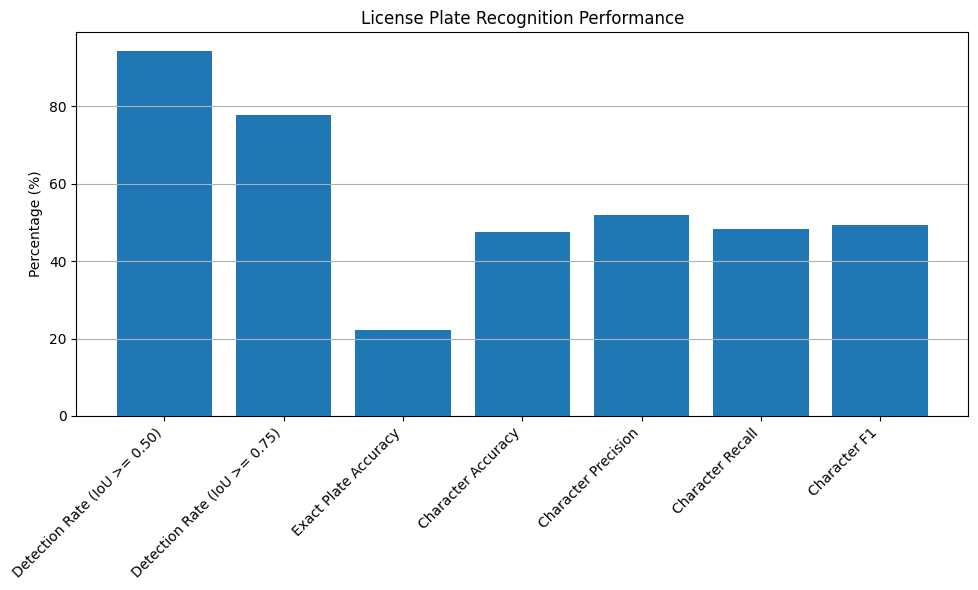

In [ ]:
plot_df = final_results[
    final_results["Metric"]
    !=
    "Mean Detection IoU"
].copy()

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    plot_df["Metric"],
    plot_df["Percentage"]
)

plt.ylabel(
    "Percentage (%)"
)

plt.title(
    "License Plate Recognition Performance"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y"
)

plt.tight_layout()

plt.show()

In [ ]:
MODEL_PATH = (
    "/content/sample_data/model/license_plate_cnn.keras"
)

model.save(
    MODEL_PATH
)

print(
    "Model saved:"
)

print(
    MODEL_PATH
)

Model saved:
/content/sample_data/model/license_plate_cnn.keras


In [ ]:
cnn_results.to_csv(
    "/content/cnn_detection_results.csv",
    index=False
)

ocr_results.to_csv(
    "/content/ocr_results.csv",
    index=False
)

final_results.to_csv(
    "/content/final_results.csv",
    index=False
)

print(
    "Results saved successfully."
)

Results saved successfully.


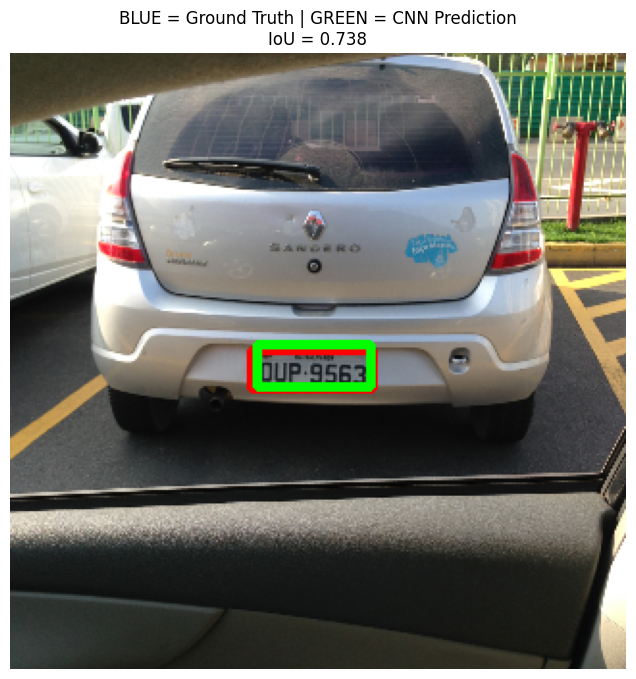

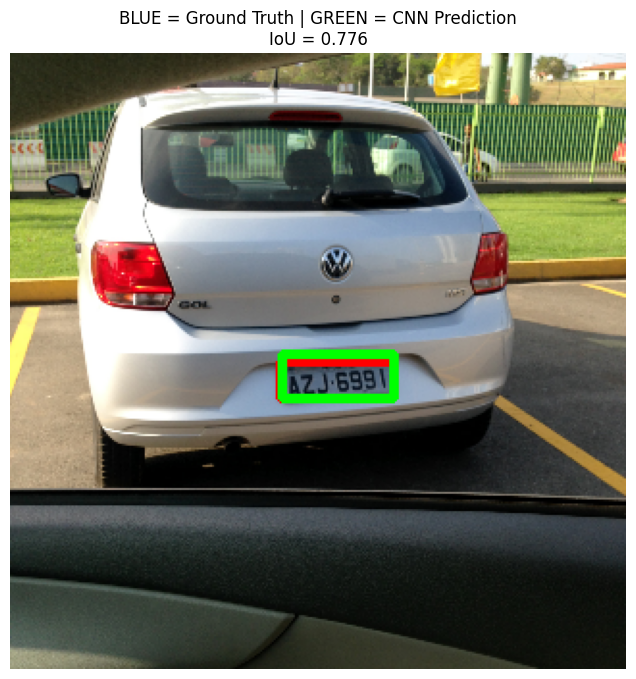

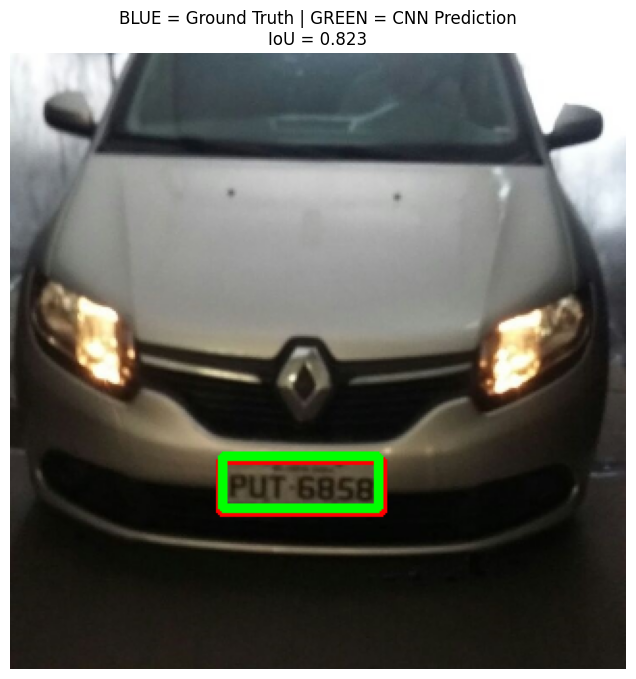

In [ ]:
show_prediction(0)
show_prediction(1)
show_prediction(2)

Ground Truth: OUP9563
OCR Prediction: OUP9563


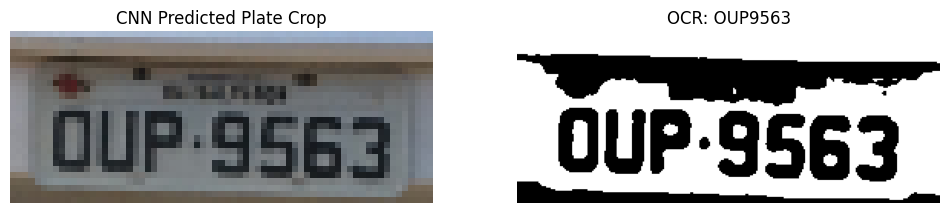

Ground Truth: OZL2318
OCR Prediction: OZ02318


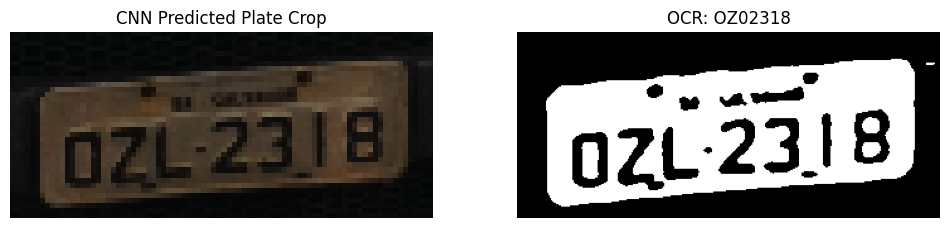

Ground Truth: PJC4903
OCR Prediction: PJC4903


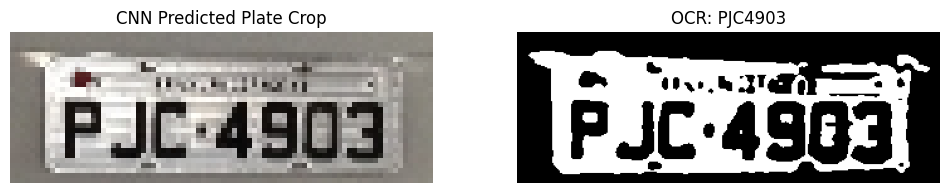

In [ ]:
show_ocr_prediction(0)
show_ocr_prediction(7)
show_ocr_prediction(9)